# Lab 1: Quantum States and Measurement with NumPy

> **Target audience:** Physics students who completed Lab 0 and already know basic linear algebra, complex numbers, Dirac notation, and the Born rule.
> This lab comes **before Lecture 1** on quantum circuits and gates.

---

[Homework and assignments](https://github.com/DamirGadiev/pwr-quantum-computing-2026)

## Purpose

In this lab you will work entirely with **state vectors, matrices, and measurement rules** using NumPy.
The goal is to become comfortable with the computational side of single-qubit quantum mechanics **before** introducing gates and circuit diagrams.

You will build the mathematical objects yourself and use them on standard quantum-information tasks.


## What You Will Practice

| Part | Topic | Main ideas | Suggested time |
|---|---|---|---|
| 1 | State-vector toolkit | normalization, bras, inner products, projectors | 20 min |
| 2 | Measurement in different bases | Z, X, Y bases; probabilities; collapse | 25 min |
| 3 | Observables and expectation values | Pauli matrices, variances, physical interpretation | 20 min |
| 4 | Phase and time evolution | global vs relative phase, simple Hamiltonian evolution | 20 min |
| 5 | Optional extension | tensor products, Bell states, correlations | 15 min |

> **Core path:** Parts 1-4

> **Optional extension:** Part 5


## Lab Rules

1. Work in order.
2. Use **NumPy only** for the core tasks.
3. For each task, write the code, test it on at least one example, and explain the physics in one or two sentences.
4. When asked for interpretation, do not just report numbers. State what those numbers mean physically.
5. If you finish early, continue to the optional extension.

## Deliverables

By the end of the lab you should have:

- functions that manipulate quantum states and observables,
- numerical checks of standard single-qubit results,
- short written interpretations for each major part,
- at least one plot in Part 4.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

ket0 = np.array([[1], [0]], dtype=complex)
ket1 = np.array([[0], [1]], dtype=complex)

print('Starter cell loaded. Run the test cells after your implementation cells.')



Starter cell loaded. Run the test cells after your implementation cells.


In [2]:
# Public validation helpers. You do not need to edit this cell.

def _as_col(v):
    arr = np.asarray(v, dtype=complex)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    return arr


def _as_matrix(m):
    return np.asarray(m, dtype=complex)


def _norm_ref(v):
    ket = _as_col(v)
    return float(np.sqrt(np.vdot(ket, ket).real))


def _normalize_ref(v):
    ket = _as_col(v)
    n = _norm_ref(ket)
    if np.isclose(n, 0.0):
        raise ValueError('Zero vector cannot be normalized.')
    return ket / n


def _same_state(a, b, tol=1e-7):
    a = _normalize_ref(a)
    b = _normalize_ref(b)
    if a.shape != b.shape:
        return False
    flat_b = b.flatten()
    idx = int(np.argmax(np.abs(flat_b)))
    if np.abs(flat_b[idx]) < tol:
        return np.allclose(a, b, atol=tol)
    phase = a.flatten()[idx] / flat_b[idx]
    return np.allclose(a, phase * b, atol=tol)


def _is_projector(P, tol=1e-7):
    P = _as_matrix(P)
    return np.allclose(P, P.conj().T, atol=tol) and np.allclose(P @ P, P, atol=tol)


def _basis_list(basis):
    if isinstance(basis, np.ndarray):
        if basis.ndim == 2 and basis.shape[1] == 2:
            return [basis[:, [0]], basis[:, [1]]]
        if basis.ndim == 2 and basis.shape[0] == 2:
            return [basis[[0], :].T, basis[[1], :].T]
    return list(basis)


def _coerce_probs(result, labels=None):
    if isinstance(result, dict):
        if labels is not None and all(label in result for label in labels):
            arr = np.array([result[label] for label in labels], dtype=float)
        else:
            arr = np.array(list(result.values()), dtype=float)
    else:
        arr = np.asarray(result, dtype=float).reshape(-1)
    return arr


def _extract_measurement_output(result, labels):
    label = None
    state = None
    probs = None
    if isinstance(result, dict):
        label = result.get('label', result.get('outcome', None))
        if label is None and 'index' in result:
            label = labels[int(result['index'])]
        state = result.get('state', result.get('post_state', None))
        probs = result.get('probabilities', result.get('probs', None))
    elif isinstance(result, (tuple, list)):
        if len(result) == 2:
            label, state = result
        elif len(result) >= 3:
            label = result[0]
            probs = result[1]
            state = result[2]
    else:
        raise AssertionError('Measurement output must be a dict, tuple, or list.')

    if isinstance(label, (int, np.integer)):
        label = labels[int(label)]

    assert label in labels, f'Outcome label must be one of {labels}, got {label!r}'
    assert state is not None, 'Measurement result must include the post-measurement state.'
    return label, _as_col(state), probs


def _computational_probs_ref(psi):
    ket = _normalize_ref(psi).flatten()
    n = int(np.log2(len(ket)))
    labels = [format(i, f'0{n}b') for i in range(len(ket))]
    return {label: float(abs(amplitude) ** 2) for label, amplitude in zip(labels, ket)}


def _mod_2pi_close(value, target, tol=0.08):
    return np.isclose(((value - target + np.pi) % (2 * np.pi)) - np.pi, 0.0, atol=tol)

print('Validation helpers loaded.')



Validation helpers loaded.


---

# Part 1 - Build a Minimal Quantum-State Toolkit

> **Goal:** Turn the abstract notation from Lab 0 into reusable computational tools.

In this part you will treat a qubit state as a complex column vector in $\mathbb{C}^2$ and implement the basic operations needed later in the lab.

A large part of beginner confusion in quantum information comes from switching too quickly between formulas, notation, and software without making the connections explicit. Here you will slow that process down. A ket such as $|\psi\rangle$ is not just a symbolic object: in computation it becomes an array of complex amplitudes, and every physically meaningful statement about the state must be recoverable from linear algebra. Normalization means total probability equals one, the bra is the conjugate transpose needed for complex inner products, and a projector is the matrix form of asking whether a state has a particular component along a direction in Hilbert space. By building these operations yourself, you are effectively creating a small numerical version of the postulates you already know from quantum mechanics.


### Task 1.1 - Validate and normalize states

Create tools that:

- check whether a candidate state has the correct shape,
- compute its norm,
- normalize it,
- verify numerically that $\langle \psi | \psi \rangle = 1$ after normalization.

Test your implementation on:

- a real vector proportional to $|0\rangle + |1\rangle$,
- a complex vector proportional to $|0\rangle + i|1\rangle$,
- one invalid input of your choice.

Write one sentence explaining why normalization is required in quantum mechanics.


In [3]:
# Your code here
# Define: state_shape_ok(v, dim=2), norm(v), normalize(v), is_valid_state(v, dim=2).
# Use NumPy and complex arithmetic.
# The tests focus on correct input/output behavior, not on a particular implementation style.
def state_shape_ok(v, dim=2):
  length = len(v)
  if length != dim:
    return False
  return True

def norm(v):
  return np.sqrt(np.vdot(v,v))

def normalize(v):
  return v/norm(v)

def is_valid_state(v, dim=2):
  if np.isclose(norm(v), 1):
    return True
  return False


Test on normalized $|0\rangle + |1\rangle$

In [4]:
required = ['state_shape_ok', 'norm', 'normalize', 'is_valid_state']
for name in required:
    assert name in globals() and callable(globals()[name]), f'Missing function: {name}'

v1 = np.array([1, 0], dtype=complex)
v2 = np.array([0, 1], dtype=complex)
v = v1+v2
normalized = normalize(v)

assert bool(state_shape_ok(np.array(v1, dtype=complex)))
assert bool(state_shape_ok(np.array(v2, dtype=complex)))
assert bool(state_shape_ok(np.array(v, dtype=complex)))
assert np.isclose(norm(v), np.sqrt(2))
assert _same_state(normalized, _normalize_ref(v))
assert bool(is_valid_state(_normalize_ref(v)))
assert not bool(is_valid_state(v))

print('Task 1.1 checks passed.')



Task 1.1 checks passed.


Test on normalized $|0\rangle + i|1\rangle$

In [5]:
required = ['state_shape_ok', 'norm', 'normalize', 'is_valid_state']
for name in required:
    assert name in globals() and callable(globals()[name]), f'Missing function: {name}'

v1 = np.array([1, 0], dtype=complex)
v2 = np.array([0, 1j], dtype=complex)
v = v1+v2
normalized = normalize(v)

assert bool(state_shape_ok(np.array(v1, dtype=complex)))
assert bool(state_shape_ok(np.array(v2, dtype=complex)))
assert bool(state_shape_ok(np.array(v, dtype=complex)))
assert np.isclose(norm(v), np.sqrt(2))
assert _same_state(normalized, _normalize_ref(v))
assert bool(is_valid_state(_normalize_ref(v)))
assert not bool(is_valid_state(v))

print('Task 1.1 checks passed.')



Task 1.1 checks passed.


Test on invalid input

In [6]:
# This cell produces an error since I wanted to show an invalid state


required = ['state_shape_ok', 'norm', 'normalize', 'is_valid_state']
for name in required:
    assert name in globals() and callable(globals()[name]), f'Missing function: {name}'

v1 = np.array([1, 0, 5], dtype=complex)
v = v1
normalized = normalize(v)

assert bool(state_shape_ok(np.array(v1, dtype=complex)))
assert bool(state_shape_ok(np.array(v, dtype=complex)))
assert np.isclose(norm(v), np.sqrt(2))
assert _same_state(normalized, _normalize_ref(v))
assert bool(is_valid_state(_normalize_ref(v)))
assert not bool(is_valid_state(v))

print('Task 1.1 checks passed.')



AssertionError: 

Normalization is important in quantum mechanics as we want to work on real quantum states in Hilbert space

### Task 1.2 - Bras, inner products, and projectors

Implement routines for:

- converting a ket $|\psi\rangle$ into a bra $\langle \psi |$,
- computing inner products $\langle \phi | \psi \rangle$,
- constructing projectors such as $|\psi\rangle\langle\psi|$.

Use your routines to verify the following claims:

1. $\langle 0|1\rangle = 0$.
2. $\langle +|-\rangle = 0$.
3. The projector onto $|0\rangle$ leaves $|0\rangle$ unchanged and annihilates $|1\rangle$.

Add a short explanation of what a projector means physically.


In [9]:
# Your code here
# Define: bra(v), inner(phi, psi), projector(psi).
# Your projector should represent the rank-1 projector onto the normalized state |psi>.
def bra(v):
  return v.conj().T

def inner(phi,psi):
  return np.vdot(phi,psi)

def projector(psi):
  return np.outer(psi,bra(psi))

Testing:

$\langle 0|1\rangle = 0$

$\langle +|-\rangle = 0$

In [10]:
required = ['bra', 'inner', 'projector']
for name in required:
    assert name in globals() and callable(globals()[name]), f'Missing function: {name}'

ket_plus_ref = _normalize_ref(ket0 + ket1)
ket_minus_ref = _normalize_ref(ket0 - ket1)
P_plus = _as_matrix(projector(ket_plus_ref))

assert _as_matrix(bra(ket1)).shape == (1, 2)
assert np.isclose(inner(ket0, ket1), 0.0)
assert np.isclose(inner(ket_plus_ref, ket_minus_ref), 0.0, atol=1e-7)
assert P_plus.shape == (2, 2)
assert _is_projector(P_plus)
assert np.allclose(P_plus @ ket_plus_ref, ket_plus_ref, atol=1e-7)
assert np.allclose(P_plus @ ket_minus_ref, np.zeros((2, 1)), atol=1e-7)

print('Task 1.2 checks passed.')



Task 1.2 checks passed.


The projector onto $|0\rangle$ leaves $|0\rangle$ unchanged and annihilates $|1\rangle$.

In [11]:
P_zero = _as_matrix(projector(ket0))

assert np.allclose(P_zero @ ket0, ket0, atol=1e-7)
assert np.allclose(P_zero @ ket1, np.zeros((2, 1)), atol=1e-7)

print('Task 1.2 checks passed.')

Task 1.2 checks passed.


Projector in physical terms means that we are projecting quantum state on a certain quantum state which loses some quantum information

### Checkpoint 1

Using only the tools from Part 1, compute the projector onto
$$
|+i\rangle = \frac{|0\rangle + i|1\rangle}{\sqrt{2}}.
$$

Then verify that applying this projector to $|+i\rangle$ returns the same state up to numerical precision.


In [12]:
# Your code here
# Define P_plus_i as the projector onto |+i> = (|0> + i|1>) / sqrt(2).
# You may define any intermediate variables you need.
state = (ket0 + 1j*ket1)/np.sqrt(2)
P_plus_i = _as_matrix(projector(state))



Testing

In [13]:
assert 'P_plus_i' in globals(), 'Define P_plus_i in the checkpoint cell.'
ket_plus_i_ref = _normalize_ref(np.array([1, 1j], dtype=complex))
P = _as_matrix(P_plus_i)

assert P.shape == (2, 2)
assert _is_projector(P)
assert np.allclose(P @ ket_plus_i_ref, ket_plus_i_ref, atol=1e-7)

print('Checkpoint 1 checks passed.')



Checkpoint 1 checks passed.


---

# Part 2 - Measurement in Different Bases

> **Goal:** See clearly that measurement outcomes depend on the basis, not only on the state vector entries written in one preferred form.

One of the most important conceptual shifts from classical information to quantum mechanics is that the same physical state can look simple or complicated depending on the basis in which it is described. Writing a qubit as a column vector in the computational basis can tempt you to think that those entries are the whole story, but they are only amplitudes relative to one chosen basis. Measurement is defined with respect to an orthonormal set of states, and changing that set changes the questions you are asking the system. This is why $|0\rangle$ is perfectly definite in the Z basis but gives a nontrivial distribution in the X basis, and why relative phase can be invisible in one basis yet observable in another. In this part, the Born rule becomes a practical tool rather than a sentence in a textbook.


### Task 2.1 - Define the standard single-qubit bases

Construct the basis vectors for:

- the computational basis: $\{|0\rangle, |1\rangle\}$,
- the X basis: $\{|+\rangle, |-\rangle\}$,
- the Y basis: $\{|+i\rangle, |-i\rangle\}$.

For each basis, verify numerically that:

- each basis vector is normalized,
- distinct basis vectors are orthogonal.

State what makes a set of vectors a valid measurement basis.


In [14]:
# Your code here
# Define: ket_plus, ket_minus, ket_plus_i, ket_minus_i.
# Define: basis_z, basis_x, basis_y as 2-element collections of basis vectors.
# Any order is acceptable as long as each basis contains the correct states.
ket0 = np.array([[1], [0]], dtype=complex)
ket1 = np.array([[0], [1]], dtype=complex)

ket_plus = (ket0 + ket1)/np.sqrt(2)
ket_minus = (ket0 - ket1)/np.sqrt(2)
ket_plus_i = (ket0 + 1j*ket1)/np.sqrt(2)
ket_minus_i = (ket0 - 1j*ket1)/np.sqrt(2)

basis_z = [ket0, ket1]
basis_x = [ket_plus, ket_minus]
basis_y = [ket_plus_i, ket_minus_i]



Verification

In [15]:
np.allclose(ket0, normalize(ket0), atol=1e-7)
np.allclose(ket1, normalize(ket1), atol=1e-7)

np.allclose(ket_plus, normalize(ket_plus), atol=1e-7)
np.allclose(ket_minus, normalize(ket_minus), atol=1e-7)

np.allclose(ket_plus_i, normalize(ket_plus_i), atol=1e-7)
np.allclose(ket_minus_i, normalize(ket_minus_i), atol=1e-7)

True

In [16]:
print(np.vdot(ket0,ket1))
print(np.vdot(ket_plus,ket_minus))
print(np.vdot(ket_plus_i,ket_minus_i))

0j
0j
0j


In [17]:
required = ['ket_plus', 'ket_minus', 'ket_plus_i', 'ket_minus_i', 'basis_z', 'basis_x', 'basis_y']
for name in required:
    assert name in globals(), f'Missing variable: {name}'

assert _same_state(ket_plus, _normalize_ref(ket0 + ket1))
assert _same_state(ket_minus, _normalize_ref(ket0 - ket1))
assert _same_state(ket_plus_i, _normalize_ref(np.array([1, 1j], dtype=complex)))
assert _same_state(ket_minus_i, _normalize_ref(np.array([1, -1j], dtype=complex)))

expected_bases = {
    'basis_z': [ket0, ket1],
    'basis_x': [_normalize_ref(ket0 + ket1), _normalize_ref(ket0 - ket1)],
    'basis_y': [_normalize_ref(np.array([1, 1j], dtype=complex)), _normalize_ref(np.array([1, -1j], dtype=complex))],
}

for basis_name, expected_states in expected_bases.items():
    basis = _basis_list(globals()[basis_name])
    assert len(basis) == 2, f'{basis_name} should contain exactly two basis vectors.'
    for vec in basis:
        assert np.isclose(_norm_ref(vec), 1.0)
    assert np.isclose(np.vdot(_as_col(basis[0]), _as_col(basis[1])), 0.0, atol=1e-7)
    for target in expected_states:
        assert any(_same_state(vec, target) for vec in basis), f'{basis_name} is missing an expected basis vector.'

print('Task 2.1 checks passed.')



Task 2.1 checks passed.


Set of vectors is a valid measurement basis when the vector are orthonormal and are true for absoluteness condition

### Task 2.2 - Compute measurement probabilities in an arbitrary basis

Write a routine that takes a normalized state $|\psi\rangle$ and an orthonormal basis $\{|b_0\rangle, |b_1\rangle\}$ and returns the probabilities
$$
P(b_k) = |\langle b_k|\psi\rangle|^2.
$$

Apply it to the following states:

1. $|0\rangle$
2. $|+\rangle$
3. $|+i\rangle$
4. $\sqrt{3/4}|0\rangle + \sqrt{1/4}|1\rangle$

For each state, compute probabilities in the Z, X, and Y bases.

Summarize your results in a table and comment on which basis makes each state look most "definite".


In [18]:
# Your code here
# Define measurement_probabilities(psi, basis, labels=None).
# A dict keyed by labels is recommended when labels are provided.
# A NumPy array, list, or tuple of probabilities is also acceptable.
def measurement_probabilities(psi, basis, labels=None):
  prob = []
  for base in basis:
    prob.append(np.abs(inner(base,psi))**2)
  return prob

Computing

In [19]:
ket4 = np.sqrt(3/4)*ket0 + np.sqrt(1/4)*ket1

test_states = [ket0, ket_plus, ket_plus_i, ket4]
basis = [basis_z, basis_x, basis_y]

for base in basis:
  print(base)
  print()
  for state in test_states:
    print(measurement_probabilities(state, base))
  print()

[array([[1.+0.j],
       [0.+0.j]]), array([[0.+0.j],
       [1.+0.j]])]

[np.float64(1.0), np.float64(0.0)]
[np.float64(0.4999999999999999), np.float64(0.4999999999999999)]
[np.float64(0.4999999999999999), np.float64(0.4999999999999999)]
[np.float64(0.7499999999999999), np.float64(0.25)]

[array([[0.7071+0.j],
       [0.7071+0.j]]), array([[ 0.7071+0.j],
       [-0.7071+0.j]])]

[np.float64(0.4999999999999999), np.float64(0.4999999999999999)]
[np.float64(0.9999999999999996), np.float64(0.0)]
[np.float64(0.4999999999999999), np.float64(0.4999999999999999)]
[np.float64(0.9330127018922192), np.float64(0.06698729810778066)]

[array([[0.7071+0.j    ],
       [0.    +0.7071j]]), array([[0.7071+0.j    ],
       [0.    -0.7071j]])]

[np.float64(0.4999999999999999), np.float64(0.4999999999999999)]
[np.float64(0.4999999999999999), np.float64(0.4999999999999999)]
[np.float64(0.9999999999999996), np.float64(0.0)]
[np.float64(0.4999999999999999), np.float64(0.4999999999999999)]



Basis_z
| - | ket_0 | ket_1 |
|---|---|---|
| ket_0 | 1.0 | 0.0 |
| ket_plus | 0.5 | 0.5 |
| ket_plus_i | 0.5 | 0.5 |
| ket_4 | 0.75 | 0.25 |

Basis_x
| - | ket_plus | ket_minus |
|---|---|---|
| ket_0 | 0.5 | 0.5 |
| ket_plus | 1.0 | 0.0 |
| ket_plus_i | 0.5 | 0.5 |
| ket_4 | 0.93 | 0.07 |

Basis_y
| - | ket_plus_i | ket_minus_i |
|---|---|---|
| ket_0 | 0.5 | 0.5 |
| ket_plus | 0.5 | 0.5 |
| ket_plus_i | 1.0 | 0.0 |
| ket_4 | 0.5 | 0.5 |

"The most definite" basis is for the states that are the same as states in the basis

In [20]:
assert 'measurement_probabilities' in globals() and callable(measurement_probabilities), 'Define measurement_probabilities.'

probs_z_0 = _coerce_probs(measurement_probabilities(ket0, [ket0, ket1], ['0', '1']), ['0', '1'])
probs_x_plus = _coerce_probs(measurement_probabilities(_normalize_ref(ket0 + ket1), [_normalize_ref(ket0 + ket1), _normalize_ref(ket0 - ket1)], ['+', '-']), ['+', '-'])
probs_z_plus_i = _coerce_probs(measurement_probabilities(_normalize_ref(np.array([1, 1j], dtype=complex)), [ket0, ket1], ['0', '1']), ['0', '1'])

assert probs_z_0.shape == (2,)
assert np.allclose(probs_z_0, [1.0, 0.0], atol=1e-7)
assert np.allclose(probs_x_plus, [1.0, 0.0], atol=1e-7)
assert np.allclose(probs_z_plus_i, [0.5, 0.5], atol=1e-7)
assert np.isclose(probs_z_plus_i.sum(), 1.0)

print('Task 2.2 checks passed.')



Task 2.2 checks passed.


### Task 2.3 - Simulate projective measurement and collapse

Design a routine that performs an ideal projective measurement in a chosen basis.
It should:

- compute the possible outcomes and their probabilities,
- sample one outcome,
- return the post-measurement state.

Use this routine on the state $|+\rangle$ measured in the Z basis.
Repeat the experiment many times and estimate the frequencies.

Then test the collapse rule explicitly:

1. measure once in the Z basis,
2. immediately measure again in the same basis,
3. explain why the second result behaves differently from the first.


In [21]:
# Your code here
# Define measure_state(psi, basis, labels=None, rng=None).
# The return value may be a dict or a tuple/list.
# It must include the measurement outcome and the post-measurement state.
def measure_state(psi, basis, labels=None, rng=None):
  if rng is None:
      rng = np.random.default_rng()

  probs_array = measurement_probabilities(psi, basis)

  outcome_index = rng.choice(len(basis), p=probs_array)
  outcome_state_vector = basis[outcome_index]

  outcome_label = labels[outcome_index] if labels else outcome_index

  return {
      'label': outcome_label,
      'probabilities': probs_array,
      'state': outcome_state_vector
  }

In [22]:
assert 'measure_state' in globals() and callable(measure_state), 'Define measure_state.'

labels = ['0', '1']
result = measure_state(_normalize_ref(ket0 + ket1), [ket0, ket1], labels, rng=np.random.default_rng(12345))
outcome, state, probs = _extract_measurement_output(result, labels)
assert outcome in labels
assert _same_state(state, ket0) or _same_state(state, ket1)
if probs is not None:
    probs_arr = _coerce_probs(probs, labels)
    assert np.allclose(probs_arr, [0.5, 0.5], atol=1e-7)

repeat = measure_state(state, [ket0, ket1], labels, rng=np.random.default_rng(2024))
outcome_repeat, state_repeat, _ = _extract_measurement_output(repeat, labels)
assert outcome_repeat == outcome
assert _same_state(state_repeat, state)

print('Task 2.3 checks passed.')



Task 2.3 checks passed.


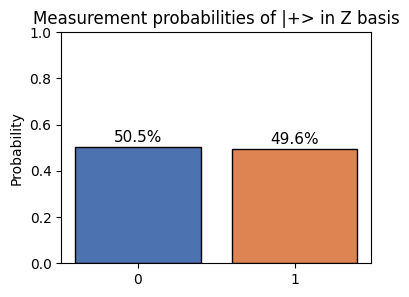

In [23]:
state = ket_plus
t = 1000
prob_0 = 0
prob_1 = 0

for t in range(t):
  measure_plus = measure_state(state, basis_z, ['0', '1'], rng=np.random.default_rng())
  if measure_plus['label'] == '0':
    prob_0 += 1
  else:
    prob_1 += 1

prob_0 = prob_0/t
prob_1 = prob_1/t

#print(prob_0)
#print(prob_1)

outcomes = ['0', '1']
probs = [prob_0, prob_1]

plt.figure(figsize=(4, 3))
bars = plt.bar(outcomes, probs, color=['#4C72B0', '#DD8452'], edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('Probability')
plt.title('Measurement probabilities of |+> in Z basis')
for bar, p in zip(bars, probs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{p:.1%}', ha='center', fontsize=11)
plt.show()

In [24]:
state = ket_plus
measure_plus = measure_state(state, basis_z, ['0', '1'], rng=np.random.default_rng())
print(measure_plus)
new_state = measure_plus['state']
measure_new_state = measure_state(new_state, basis_z, ['0', '1'], rng=np.random.default_rng())
print(measure_new_state)

{'label': '0', 'probabilities': [np.float64(0.4999999999999999), np.float64(0.4999999999999999)], 'state': array([[1.+0.j],
       [0.+0.j]])}
{'label': '0', 'probabilities': [np.float64(1.0), np.float64(0.0)], 'state': array([[1.+0.j],
       [0.+0.j]])}


In the second measurement we always receive one state with 100% probability, while the second state is always observed with 0% probability. It is because performing measurement collapses the state, we are applying projector operator.

### Checkpoint 2

Find two different normalized states that give the **same probabilities in the Z basis** but **different probabilities in the X basis**.

Compute the probabilities explicitly and explain what physical feature distinguishes the two states.


In [25]:
# Your code here
# Define two different normalized states psi_a and psi_b.
# They should have the same Z-basis probabilities but different X-basis probabilities.
psi_a = (ket0 + ket1)/np.sqrt(2)
psi_b = (ket0 - ket1)/np.sqrt(2)

print(measurement_probabilities(psi_a, basis_x))
print(measurement_probabilities(psi_b, basis_x))
print()
print(measurement_probabilities(psi_a, basis_z))
print(measurement_probabilities(psi_b, basis_z))

[np.float64(0.9999999999999996), np.float64(0.0)]
[np.float64(0.0), np.float64(0.9999999999999996)]

[np.float64(0.4999999999999999), np.float64(0.4999999999999999)]
[np.float64(0.4999999999999999), np.float64(0.4999999999999999)]


The physical feature distinguishing the two states might be different magnetic projection number. In terms of quantum computing, these states differ in relative phase (which is distinguishible), in opposite to global phase (indistinguishible).

In [26]:
required = ['psi_a', 'psi_b']
for name in required:
    assert name in globals(), f'Missing variable: {name}'

z_a = _coerce_probs(measurement_probabilities(psi_a, [ket0, ket1], ['0', '1']), ['0', '1'])
z_b = _coerce_probs(measurement_probabilities(psi_b, [ket0, ket1], ['0', '1']), ['0', '1'])
x_a = _coerce_probs(measurement_probabilities(psi_a, [_normalize_ref(ket0 + ket1), _normalize_ref(ket0 - ket1)], ['+', '-']), ['+', '-'])
x_b = _coerce_probs(measurement_probabilities(psi_b, [_normalize_ref(ket0 + ket1), _normalize_ref(ket0 - ket1)], ['+', '-']), ['+', '-'])

assert np.allclose(z_a, z_b, atol=1e-7)
assert not np.allclose(x_a, x_b, atol=1e-7)

print('Checkpoint 2 checks passed.')



Checkpoint 2 checks passed.


---

# Part 3 - Observables, Expectation Values, and Uncertainty

> **Goal:** Connect qubit states to familiar quantum-mechanical observables.

In this part, treat the Pauli matrices as observables for a spin-1/2 system.

Up to this point, you have mainly described states and probabilities. Now the focus shifts to observables, which is where the qubit starts to look exactly like the spin-1/2 systems from standard quantum mechanics. The Pauli matrices are not introduced here as gates or circuit elements; they are Hermitian operators with real expectation values and well-defined measurement statistics. Computing $\langle \psi | A | \psi \rangle$ numerically forces you to connect algebraic expressions to physical meaning: an expectation value is not a mysterious average, but the statistical mean of repeated measurements on identically prepared systems. Variance then quantifies how sharp or uncertain the observable is in a given state. When a variance is zero, the state is an eigenstate of the observable, and when it is nonzero, the state carries intrinsic quantum uncertainty rather than simple ignorance.


### Task 3.1 - Expectation values of the Pauli observables

Define the matrices $\sigma_x$, $\sigma_y$, and $\sigma_z$.

Write a routine that computes the expectation value
$$
\langle A \rangle = \langle \psi | A | \psi \rangle.
$$

Evaluate $\langle \sigma_x \rangle$, $\langle \sigma_y \rangle$, and $\langle \sigma_z \rangle$ for:

- $|0\rangle$
- $|1\rangle$
- $|+\rangle$
- $|-\rangle$
- $|+i\rangle$

Interpret each result physically as a preferred measurement axis.


In [27]:
# Your code here
# Define sigma_x, sigma_y, sigma_z as 2x2 NumPy arrays.
# Define expectation(psi, operator).
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

def expectation(psi, operator):
  return np.vdot(psi, operator @ psi).real

In [28]:
required = ['sigma_x', 'sigma_y', 'sigma_z', 'expectation']
for name in required:
    assert name in globals(), f'Missing name: {name}'
assert callable(expectation), 'expectation must be callable.'

for matrix_name in ['sigma_x', 'sigma_y', 'sigma_z']:
    matrix = _as_matrix(globals()[matrix_name])
    assert matrix.shape == (2, 2)
    assert np.allclose(matrix, matrix.conj().T), f'{matrix_name} must be Hermitian.'

assert np.isclose(expectation(ket0, sigma_z), 1.0, atol=1e-7)
assert np.isclose(expectation(ket1, sigma_z), -1.0, atol=1e-7)
assert np.isclose(expectation(_normalize_ref(ket0 + ket1), sigma_x), 1.0, atol=1e-7)
assert np.isclose(expectation(_normalize_ref(np.array([1, 1j], dtype=complex)), sigma_y), 1.0, atol=1e-7)

print('Task 3.1 checks passed.')



Task 3.1 checks passed.


In [29]:
test_states = [ket0, ket1, ket_plus, ket_minus, ket_plus_i]
observables = [sigma_x, sigma_y, sigma_z]

for state in test_states:
  print(state)
  print()
  for obs in observables:
    print(expectation(state, obs))
  print()

[[1.+0.j]
 [0.+0.j]]

0.0
0.0
1.0

[[0.+0.j]
 [1.+0.j]]

0.0
0.0
-1.0

[[0.7071+0.j]
 [0.7071+0.j]]

0.9999999999999998
0.0
0.0

[[ 0.7071+0.j]
 [-0.7071+0.j]]

-0.9999999999999998
0.0
0.0

[[0.7071+0.j    ]
 [0.    +0.7071j]]

0.0
0.9999999999999998
0.0



States from:

-basis_x: x-axis

-basis_y: y-axis

-basis_z: z-axis

### Task 3.2 - Variance and uncertainty

For an observable $A$, compute the variance
$$
\mathrm{Var}(A) = \langle A^2 \rangle - \langle A \rangle^2.
$$

Use your code to determine the variances of $\sigma_x$, $\sigma_y$, and $\sigma_z$ for the states $|0\rangle$, $|+\rangle$, and $|+i\rangle$.

Then answer:

- In which observable is each state perfectly sharp?
- In which observables is it uncertain?
- How does this relate to basis choice from Part 2?


In [30]:
# Your code here
# Define variance(psi, operator).
# Use the formula Var(A) = <A^2> - <A>^2.
def variance(psi, operator):
  return expectation(psi, operator @ operator) - expectation(psi, operator)**2



In [31]:
assert 'variance' in globals() and callable(variance), 'Define variance.'

assert np.isclose(variance(ket0, sigma_z), 0.0, atol=1e-7)
assert np.isclose(variance(ket0, sigma_x), 1.0, atol=1e-7)
assert np.isclose(variance(_normalize_ref(ket0 + ket1), sigma_x), 0.0, atol=1e-7)
assert np.isclose(variance(_normalize_ref(np.array([1, 1j], dtype=complex)), sigma_y), 0.0, atol=1e-7)

print('Task 3.2 checks passed.')



Task 3.2 checks passed.


In [32]:
test_states = [ket0, ket_plus, ket_plus_i]
observables = [sigma_x, sigma_y, sigma_z]

for state in test_states:
  print(state)
  print()
  for obs in observables:
    print(variance(state, obs))
  print()

[[1.+0.j]
 [0.+0.j]]

1.0
1.0
0.0

[[0.7071+0.j]
 [0.7071+0.j]]

2.220446049250313e-16
0.9999999999999998
0.9999999999999998

[[0.7071+0.j    ]
 [0.    +0.7071j]]

0.9999999999999998
2.220446049250313e-16
0.9999999999999998



Perfectly sharp is for variance = 0.
That is when the state is the same state that occurs in the basis.

Uncertain is for the 2 other bases (variance = 1)

### Checkpoint 3

A student claims that the state $|+\rangle$ has "half spin-up and half spin-down in every possible measurement."

Use your numerical results to decide whether this claim is correct.
Support your answer with at least two explicit expectation values or probability calculations.


In [33]:
# Your code here
# Set claim_is_correct to either True or False after your analysis.
# The statement should be marked False if you have checked the measurements carefully.
state = ket_plus
print(expectation(state, sigma_x))
print(expectation(state, sigma_y))
print(expectation(state, sigma_z))

claim_is_correct = False



0.9999999999999998
0.0
0.0


In [34]:
assert 'claim_is_correct' in globals(), 'Define claim_is_correct.'
assert bool(claim_is_correct) is False, 'The claim should be marked as False.'

print('Checkpoint 3 checks passed.')



Checkpoint 3 checks passed.


---

# Part 4 - Phase and Time Evolution

> **Goal:** Show that phase is not just formal notation. Relative phase affects measurable predictions.

Students often accept complex amplitudes formally long before they feel why those phases matter physically. This part is meant to close that gap. A global phase multiplies the whole state by the same complex number and leaves every probability unchanged, so it has no observable effect. A relative phase, however, changes how amplitudes combine when the state is examined in another basis, and that is why interference exists at all. Time evolution provides the cleanest route to seeing this numerically. Under a Hamiltonian, components of the state acquire time-dependent phases, and even when populations in one basis stay fixed, probabilities in another basis can oscillate. In other words, phase is not decorative notation placed on top of real physics; it is part of the mechanism that determines measurable outcomes.


### Task 4.1 - Global phase versus relative phase

Compare the following three states:

$$
|\psi_1\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}, \qquad
|\psi_2\rangle = e^{i\pi/3}|\psi_1\rangle, \qquad
|\psi_3\rangle = \frac{|0\rangle + i|1\rangle}{\sqrt{2}}.
$$

Compute measurement probabilities for all three states in the Z, X, and Y bases.

Then explain:

- which two states are physically indistinguishable,
- which state differs by a relative phase,
- in which basis that difference becomes visible.


In [35]:
# Your code here
# Define psi_1, psi_2, psi_3 exactly as described in the task statement.
# You may reuse your earlier helper functions.
psi_1 = ket_plus
psi_2 = np.exp(1j*np.pi/3)*ket_plus
psi_3 = ket_plus_i

test_states = [psi_1, psi_2, psi_3]
basis = [basis_z, basis_x, basis_y]

for base in basis:
  print(base)
  print()
  for state in test_states:
    print(measurement_probabilities(state, base))
  print()



[array([[1.+0.j],
       [0.+0.j]]), array([[0.+0.j],
       [1.+0.j]])]

[np.float64(0.4999999999999999), np.float64(0.4999999999999999)]
[np.float64(0.5000000000000001), np.float64(0.5000000000000001)]
[np.float64(0.4999999999999999), np.float64(0.4999999999999999)]

[array([[0.7071+0.j],
       [0.7071+0.j]]), array([[ 0.7071+0.j],
       [-0.7071+0.j]])]

[np.float64(0.9999999999999996), np.float64(0.0)]
[np.float64(1.0), np.float64(0.0)]
[np.float64(0.4999999999999999), np.float64(0.4999999999999999)]

[array([[0.7071+0.j    ],
       [0.    +0.7071j]]), array([[0.7071+0.j    ],
       [0.    -0.7071j]])]

[np.float64(0.4999999999999999), np.float64(0.4999999999999999)]
[np.float64(0.4999999999999998), np.float64(0.4999999999999998)]
[np.float64(0.9999999999999996), np.float64(0.0)]



psi_1 and psi_2 are physically indistinguishable

psi_1 and psi_3 differ by a relative phase

that difference becomes visible in basis_y and basis_z so in those basis which doesnt contain ket0 and ket1

In [36]:
required = ['psi_1', 'psi_2', 'psi_3']
for name in required:
    assert name in globals(), f'Missing variable: {name}'

for basis, labels in [([ket0, ket1], ['0', '1']), ([_normalize_ref(ket0 + ket1), _normalize_ref(ket0 - ket1)], ['+', '-']), ([_normalize_ref(np.array([1, 1j], dtype=complex)), _normalize_ref(np.array([1, -1j], dtype=complex))], ['+i', '-i'])]:
    p1 = _coerce_probs(measurement_probabilities(psi_1, basis, labels), labels)
    p2 = _coerce_probs(measurement_probabilities(psi_2, basis, labels), labels)
    assert np.allclose(p1, p2, atol=1e-7)

z1 = _coerce_probs(measurement_probabilities(psi_1, [ket0, ket1], ['0', '1']), ['0', '1'])
z3 = _coerce_probs(measurement_probabilities(psi_3, [ket0, ket1], ['0', '1']), ['0', '1'])
y1 = _coerce_probs(measurement_probabilities(psi_1, [_normalize_ref(np.array([1, 1j], dtype=complex)), _normalize_ref(np.array([1, -1j], dtype=complex))], ['+i', '-i']), ['+i', '-i'])
y3 = _coerce_probs(measurement_probabilities(psi_3, [_normalize_ref(np.array([1, 1j], dtype=complex)), _normalize_ref(np.array([1, -1j], dtype=complex))], ['+i', '-i']), ['+i', '-i'])

assert np.allclose(z1, z3, atol=1e-7)
assert not np.allclose(y1, y3, atol=1e-7)

print('Task 4.1 checks passed.')



Task 4.1 checks passed.


### Task 4.2 - Time evolution under a simple Hamiltonian

Consider the Hamiltonian
$$
H = \frac{\omega}{2}\sigma_z.
$$

Your task is to evolve an initial state in time using
$$
U(t) = e^{-iHt}.
$$

Suggested route:

- diagonalize the Hamiltonian numerically,
- construct the time-evolution operator from the eigenvalues and eigenvectors,
- evolve the initial state $|+\rangle$ over a range of times.

For each time, compute the probabilities of measuring in the X basis.

Create a plot of $P(+)$ and $P(-)$ as functions of time and explain the oscillation physically.


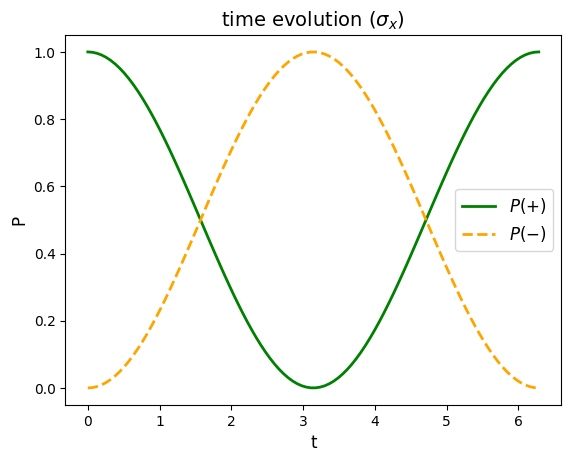

In [37]:
from os import times
# Your code here
# Define unitary_from_hamiltonian(hamiltonian, t).
# Define times, prob_plus, prob_minus for the evolution of |+> under H = (omega/2) sigma_z.
# Create a plot of the two probability curves.
def unitary_from_hamiltonian(hamiltonian, t):
  eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian)
  operator = np.diag(np.exp(-1j*eigenvalues*t))
  return eigenvectors @ operator @ eigenvectors.conj().T

omega = 1
hamiltonian = omega*0.5*sigma_z

times = np.linspace(0, 2*np.pi, 100)
prob_plus = []
prob_minus = []

for t in times:
  U = unitary_from_hamiltonian(hamiltonian, t)
  state = U @ ket_plus
  prob = measurement_probabilities(state, basis_x)
  prob_plus.append(prob[0])
  prob_minus.append(prob[1])

plt.plot(times, prob_plus, label=r'$P(+)$', color='green', linewidth=2)
plt.plot(times, prob_minus, label=r'$P(-)$', color='orange', linestyle='--', linewidth=2)
plt.legend(fontsize=12)
plt.title(r'time evolution ($\sigma_x$)', fontsize=14)
plt.xlabel('t', fontsize=12)
plt.ylabel('P', fontsize=12)
plt.show()



In [38]:
required = ['unitary_from_hamiltonian', 'times', 'prob_plus', 'prob_minus']
for name in required:
    assert name in globals(), f'Missing name: {name}'
assert callable(unitary_from_hamiltonian), 'unitary_from_hamiltonian must be callable.'

H_test = 0.5 * sigma_z
U0 = _as_matrix(unitary_from_hamiltonian(H_test, 0.0))
U_pi = _as_matrix(unitary_from_hamiltonian(H_test, np.pi))
assert U0.shape == (2, 2)
assert np.allclose(U0.conj().T @ U0, np.eye(2), atol=1e-7)
assert np.allclose(U_pi.conj().T @ U_pi, np.eye(2), atol=1e-7)
assert _same_state(U_pi @ _normalize_ref(ket0 + ket1), _normalize_ref(ket0 - ket1))

times_arr = np.asarray(times, dtype=float).reshape(-1)
prob_plus_arr = np.asarray(prob_plus, dtype=float).reshape(-1)
prob_minus_arr = np.asarray(prob_minus, dtype=float).reshape(-1)

assert len(times_arr) == len(prob_plus_arr) == len(prob_minus_arr)
assert len(times_arr) >= 50
assert np.allclose(prob_plus_arr + prob_minus_arr, 1.0, atol=1e-6)
assert np.allclose(prob_plus_arr, np.cos(times_arr / 2) ** 2, atol=1e-5)
assert np.allclose(prob_minus_arr, np.sin(times_arr / 2) ** 2, atol=1e-5)

print('Task 4.2 checks passed.')



Task 4.2 checks passed.


### Checkpoint 4

At what times in your simulation is the evolved state most similar to:

- $|+\rangle$,
- $|-\rangle$,
- $|+i\rangle$,
- $|-i\rangle$?

Use overlaps or measurement probabilities to justify your answer.


In [39]:
# Your code here
# Define best_times as a dict with the keys: |+>, |->, |+i>, |-i>.
# Each value should be a time where the evolved state is maximally aligned with that target state.
kets = {
    '|+>': ket_plus,
    '|->': ket_minus,
    '|+i>': ket_plus_i,
    '|-i>': ket_minus_i
}

best_times = {}
state = ket_plus
for i, target_state in kets.items():
  overlaps = []
  for t in times:
    overlaps.append(np.abs(np.vdot(target_state, unitary_from_hamiltonian(hamiltonian, t) @ state)))

  best_index = np.argmax(overlaps)
  best_times[i] = times[best_index]

print(best_times)


{'|+>': np.float64(0.0), '|->': np.float64(3.1098593944626236), '|+i>': np.float64(1.5866629563584815), '|-i>': np.float64(4.696522350821105)}


In [40]:
assert 'best_times' in globals(), 'Define best_times.'
expected = {'|+>': 0.0, '|->': np.pi, '|+i>': np.pi / 2, '|-i>': 3 * np.pi / 2}
for key, target in expected.items():
    assert key in best_times, f'Missing key in best_times: {key}'
    assert _mod_2pi_close(float(best_times[key]), target), f'Unexpected best time for {key}: {best_times[key]}'

print('Checkpoint 4 checks passed.')



Checkpoint 4 checks passed.


---

# Part 5 - Optional Extension: Two-Qubit States Without Circuits

> **Optional:** Attempt this only if you have completed the core path.

This part previews multi-qubit quantum information using only tensor products and state vectors.

The purpose of this extension is to show that multi-qubit quantum information does not begin with circuit notation. It begins with the structure of composite Hilbert spaces. When two qubits are combined, the dimension of the state space multiplies rather than adds, and the tensor product is the mathematical rule that builds the joint system from the subsystems. Product states are the straightforward combinations you would expect from independent systems, but entangled states are different: the full state is well defined even though it cannot be factored into a state of qubit A times a state of qubit B. That distinction is central to quantum information. By constructing both product states and Bell states directly as vectors, you can study correlations before any formal introduction of quantum gates or circuit diagrams.


### Task 5.1 - Build product states with tensor products

Using `np.kron`, construct the states:

- $|00\rangle$
- $|01\rangle$
- $|10\rangle$
- $|11\rangle$
- $|+0\rangle$
- $|++\rangle$

Verify normalization and compute the probabilities of all computational-basis outcomes.

Explain how the dimension changes when going from one qubit to two.


In [41]:
# Your code here
# Define: ket00, ket01, ket10, ket11, ket_plus0, ket_plusplus.
# Use np.kron for the tensor products.
pass



In [42]:
required = ['ket00', 'ket01', 'ket10', 'ket11', 'ket_plus0', 'ket_plusplus']
for name in required:
    assert name in globals(), f'Missing variable: {name}'

assert _same_state(ket00, np.kron(ket0, ket0).reshape(-1, 1))
assert _same_state(ket01, np.kron(ket0, ket1).reshape(-1, 1))
assert _same_state(ket10, np.kron(ket1, ket0).reshape(-1, 1))
assert _same_state(ket11, np.kron(ket1, ket1).reshape(-1, 1))
assert _same_state(ket_plus0, np.kron(_normalize_ref(ket0 + ket1), ket0).reshape(-1, 1))
assert _same_state(ket_plusplus, np.kron(_normalize_ref(ket0 + ket1), _normalize_ref(ket0 + ket1)).reshape(-1, 1))

for state in [ket00, ket01, ket10, ket11, ket_plus0, ket_plusplus]:
    assert _as_col(state).shape == (4, 1)
    assert np.isclose(_norm_ref(state), 1.0, atol=1e-7)

print('Task 5.1 checks passed.')



AssertionError: Missing variable: ket00

### Task 5.2 - Compare a product state and a Bell state

Construct the Bell state
$$
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}.
$$

Compare it with the product state $|++\rangle$.

For both states:

- compute computational-basis probabilities,
- compute the probability that the two qubits give the same measurement result in the Z basis,
- write two sentences describing the difference between "superposition" and "entanglement".


In [ ]:
# Your code here
# Define phi_plus, phi_probs, plusplus_probs, same_phi, same_plusplus.
# Probability outputs may be dicts or iterables.
pass



In [ ]:
required = ['phi_plus', 'phi_probs', 'plusplus_probs', 'same_phi', 'same_plusplus']
for name in required:
    assert name in globals(), f'Missing variable: {name}'

phi_ref = _normalize_ref(np.kron(ket0, ket0).reshape(-1, 1) + np.kron(ket1, ket1).reshape(-1, 1))
assert _same_state(phi_plus, phi_ref)

labels = ['00', '01', '10', '11']
phi_probs_arr = _coerce_probs(phi_probs, labels)
plusplus_probs_arr = _coerce_probs(plusplus_probs, labels)

assert np.allclose(phi_probs_arr, [0.5, 0.0, 0.0, 0.5], atol=1e-7)
assert np.allclose(plusplus_probs_arr, [0.25, 0.25, 0.25, 0.25], atol=1e-7)
assert np.isclose(float(same_phi), 1.0, atol=1e-7)
assert np.isclose(float(same_plusplus), 0.5, atol=1e-7)

print('Task 5.2 checks passed.')



---

# Fast Finishers

> **Bonus:** These tasks are optional and intended for students who finish the core lab early.

These exercises stay fully within the NumPy-based language of the lab. They do not require Qiskit or circuit notation. Instead, they push the same ideas one level further: a second representation of quantum states, a second formula for expectation values, and a second example of time evolution.



### Bonus 1 - Density Matrices for Pure States

A pure-state density matrix is defined by
$$
\rho = |\psi\rangle\langle\psi|.
$$

For a pure state, you should find three key properties:

- $\rho$ is Hermitian,
- $\mathrm{Tr}(\rho) = 1$,
- $\rho^2 = \rho$.

Tasks:

- define a function `density_matrix(psi)`,
- define `rho_plus_i` for $|+i\rangle$,
- define `trace_rho_plus_i`,
- define `purity_rho_plus_i = trace(rho_plus_i @ rho_plus_i)`.


In [ ]:
# Your code here
# Define density_matrix(psi).
# Define rho_plus_i, trace_rho_plus_i, purity_rho_plus_i.
# Hint: for a normalized ket, rho = |psi><psi| is an outer product.
pass



In [ ]:
required = ['density_matrix', 'rho_plus_i', 'trace_rho_plus_i', 'purity_rho_plus_i']
for name in required:
    assert name in globals(), f'Missing name: {name}'
assert callable(density_matrix), 'density_matrix must be callable.'

rho_test = np.asarray(density_matrix(_normalize_ref(np.array([1, 1j], dtype=complex))), dtype=complex)
rho_ref = _normalize_ref(np.array([1, 1j], dtype=complex)) @ _normalize_ref(np.array([1, 1j], dtype=complex)).conj().T

assert rho_test.shape == (2, 2)
assert np.allclose(rho_test, rho_ref, atol=1e-7)
assert np.allclose(rho_plus_i, rho_ref, atol=1e-7)
assert np.allclose(rho_test, rho_test.conj().T, atol=1e-7)
assert np.isclose(np.trace(rho_test), 1.0, atol=1e-7)
assert np.allclose(rho_test @ rho_test, rho_test, atol=1e-7)
assert np.isclose(trace_rho_plus_i, 1.0, atol=1e-7)
assert np.isclose(purity_rho_plus_i, 1.0, atol=1e-7)

print('Bonus 1 checks passed.')



### Bonus 2 - Expectation Values from the Trace Formula

For density matrices, expectation values can be computed as
$$
\langle A \rangle = \mathrm{Tr}(\rho A).
$$

Tasks:

- define a function `trace_expectation(rho, operator)`,
- define `trace_exp_x_plus_i`, `trace_exp_y_plus_i`, and `trace_exp_z_plus_i`,
- compare them with the expectation values obtained earlier from the ket formalism.

Hint: for a pure state, both methods should agree.


In [ ]:
# Your code here
# Define trace_expectation(rho, operator).
# Define trace_exp_x_plus_i, trace_exp_y_plus_i, trace_exp_z_plus_i.
# Hint: use np.trace on a matrix product.
pass



In [ ]:
required = ['trace_expectation', 'trace_exp_x_plus_i', 'trace_exp_y_plus_i', 'trace_exp_z_plus_i']
for name in required:
    assert name in globals(), f'Missing name: {name}'
assert callable(trace_expectation), 'trace_expectation must be callable.'

rho_ref = _normalize_ref(np.array([1, 1j], dtype=complex)) @ _normalize_ref(np.array([1, 1j], dtype=complex)).conj().T
val_x = trace_expectation(rho_ref, sigma_x)
val_y = trace_expectation(rho_ref, sigma_y)
val_z = trace_expectation(rho_ref, sigma_z)

assert np.isclose(val_x, 0.0, atol=1e-7)
assert np.isclose(val_y, 1.0, atol=1e-7)
assert np.isclose(val_z, 0.0, atol=1e-7)
assert np.isclose(trace_exp_x_plus_i, val_x, atol=1e-7)
assert np.isclose(trace_exp_y_plus_i, val_y, atol=1e-7)
assert np.isclose(trace_exp_z_plus_i, val_z, atol=1e-7)
assert np.isclose(val_y, expectation(_normalize_ref(np.array([1, 1j], dtype=complex)), sigma_y), atol=1e-7)

print('Bonus 2 checks passed.')



### Bonus 3 - Rabi Oscillations Under $H = \frac{\omega}{2}\sigma_x$

Reuse the time-evolution machinery from Part 4, but now evolve the initial state $|0\rangle$ under
$$
H_x = \frac{\omega}{2}\sigma_x.
$$

Tasks:

- define `times_x`, `prob_0_x`, and `prob_1_x`,
- measure in the Z basis,
- verify that the two probabilities behave like $\cos^2(t/2)$ and $\sin^2(t/2)$,
- plot the two curves.

Hint: reuse `unitary_from_hamiltonian` from Task 4.2.


In [ ]:
# Your code here
# Define times_x, prob_0_x, prob_1_x.
# Reuse unitary_from_hamiltonian and measurement_probabilities.
# Measure the evolved state in the Z basis.
pass



In [ ]:
required = ['times_x', 'prob_0_x', 'prob_1_x']
for name in required:
    assert name in globals(), f'Missing name: {name}'
assert 'unitary_from_hamiltonian' in globals() and callable(unitary_from_hamiltonian), 'Reuse unitary_from_hamiltonian from Task 4.2.'

times_arr = np.asarray(times_x, dtype=float).reshape(-1)
prob_0_arr = np.asarray(prob_0_x, dtype=float).reshape(-1)
prob_1_arr = np.asarray(prob_1_x, dtype=float).reshape(-1)

assert len(times_arr) == len(prob_0_arr) == len(prob_1_arr)
assert len(times_arr) >= 50
assert np.allclose(prob_0_arr + prob_1_arr, 1.0, atol=1e-6)
assert np.allclose(prob_0_arr, np.cos(times_arr / 2) ** 2, atol=1e-5)
assert np.allclose(prob_1_arr, np.sin(times_arr / 2) ** 2, atol=1e-5)
assert np.isclose(prob_0_arr[0], 1.0, atol=1e-7)

print('Bonus 3 checks passed.')



---

# Wrap-Up

## What you should understand after this lab

- A qubit state is a normalized complex vector.
- Measurement probabilities depend on the chosen basis.
- Projective measurement changes the state.
- Pauli matrices can be treated as observables for spin-1/2 systems.
- Relative phase affects measurable predictions.
- Time evolution can be simulated numerically with linear algebra.

## Reflection questions

1. Which part of this lab felt most like standard quantum mechanics?
2. Which part felt most like quantum information?
3. What became clearer when you computed everything numerically rather than only symbolically?
4. What do you expect a "quantum gate" to be, based on the operations you used here?

## Forward link to Lecture 1

In Lecture 1, these same objects will be reorganized into the language of:

- quantum gates as unitary operators,
- circuit diagrams,
- measurement as part of a computational workflow,
- multi-qubit quantum processes.
